In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [4]:
df_temperatura = pd.read_csv("../data/celsius_a_fahrenheit.csv")
df_temperatura.head()

,Celsius,Fahrenheit
0,-50,-58.0
1,-40,-40.0
2,-30,-22.0
3,-20,-4.0
4,-10,14.0


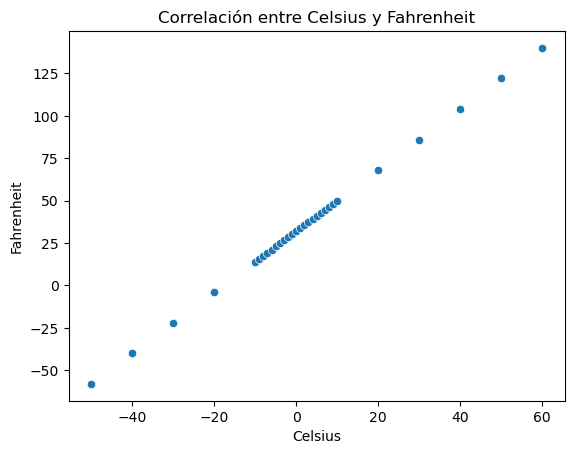

In [5]:
sns.scatterplot(x='Celsius', y='Fahrenheit', data=df_temperatura)
plt.title('Correlación entre Celsius y Fahrenheit')
plt.show()

In [6]:
X_train = df_temperatura['Celsius'].values
Y_train = df_temperatura['Fahrenheit'].values

In [9]:
oculta1 = tf.keras.layers.Dense(units=3, input_shape=[1])
oculta2 = tf.keras.layers.Dense(units=3)
salida  = tf.keras.layers.Dense(units=1)

modelo = tf.keras.Sequential([oculta1, oculta2, salida])

c:\Users\Diego\anaconda3\envs\notebook\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
modelo.compile(optimizer=tf.keras.optimizers.Adam(1.0), loss='mean_squared_error')

In [11]:
epochs_hist = modelo.fit(X_train, Y_train, epochs=100, verbose=False)

In [12]:
print("Keys:", epochs_hist.history.keys())

Keys: dict_keys(['loss'])


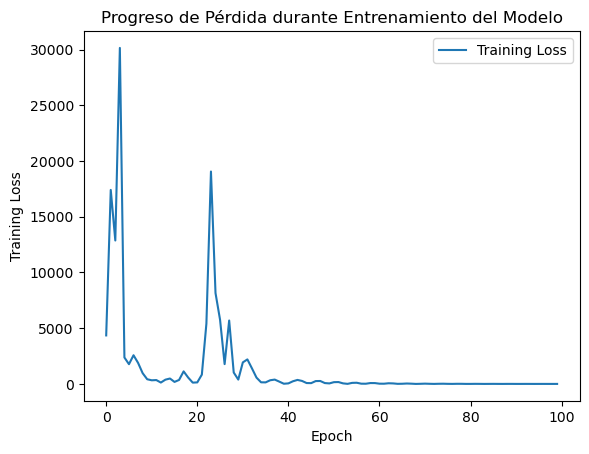

In [13]:
plt.plot(epochs_hist.history['loss'])
plt.title('Progreso de Pérdida durante Entrenamiento del Modelo')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend(['Training Loss'])
plt.show()

In [14]:
print("Pesos oculta1:", oculta1.get_weights())
print("Pesos oculta2:", oculta2.get_weights())
print("Pesos salida:", salida.get_weights())

Pesos oculta1: [array([[-0.6379994,  0.5237208,  1.7334044]], dtype=float32), array([ 4.148838 , -1.8253912,  7.0718493], dtype=float32)]
Pesos oculta2: [array([[-1.0034077 , -0.6567419 ,  0.34073836],
       [ 0.14740314, -0.9641073 ,  1.0413581 ],
       [ 1.024687  , -0.8301722 , -2.162155  ]], dtype=float32), array([-4.0403576, 16.869572 , 10.022106 ], dtype=float32)]
Pesos salida: [array([[ 0.06620198],
       [ 0.6014975 ],
       [-0.7578622 ]], dtype=float32), array([22.127375], dtype=float32)]


In [15]:
Temp_C = 100
Temp_C_array = np.array([[Temp_C]])
Temp_F = modelo.predict(Temp_C_array)
print("Temperatura de Prediccion: " + str(Temp_F))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
Temperatura de Prediccion: [[216.40749]]


In [16]:
Temp_F_formula = 9/5 * Temp_C + 32
print("Temperatura de Ecuacion: " + str(Temp_F_formula))

Temperatura de Ecuacion: 212.0


1. Optimizadores: Adam, SGD y RMSProp
Adam ajusta automáticamente la tasa de aprendizaje y converge rápido, siendo el más eficiente. SGD es más lento y básico, mientras que RMSProp es intermedio; ambos requerirían más ajuste manual y posiblemente más épocas para obtener resultados similares.

2. Función de pérdida: mean_squared_error
El MSE le indica al modelo qué tan lejos están sus predicciones, penalizando más los errores grandes. Una alternativa es MAE (mean_absolute_error), que es menos sensible a valores extremos pero converge más lento.

3. Épocas suficientes
Observando la gráfica, entre las épocas 200-300 la pérdida se estabiliza y el modelo puede considerarse entrenado. Agregar más épocas después de ese punto no mejora significativamente el resultado.

4. ¿Por qué son importantes las épocas?
Las épocas definen cuántas veces el modelo aprende de los datos; pocas causan underfitting (aprende poco) y demasiadas causan overfitting (memoriza en lugar de generalizar).

5. Función de activación y RELU
Las capas Dense usan activación lineal por defecto. Se puede cambiar a ReLU en las capas ocultas con activation='relu', dejando la capa de salida lineal para permitir predicciones negativas.